In [6]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


In [7]:
df = pd.read_csv('iris.csv')

In [8]:
df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [9]:
df = df.iloc[:,1:]

In [10]:
df.head()

,sepal.width,petal.length,petal.width,variety
0,3.5,1.4,0.2,Setosa
1,3.0,1.4,0.2,Setosa
2,3.2,1.3,0.2,Setosa
3,3.1,1.5,0.2,Setosa
4,3.6,1.4,0.2,Setosa


In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
encoder = LabelEncoder()

In [13]:
df['variety'] = encoder.fit_transform(df['variety'])

In [14]:
df.head()

,sepal.width,petal.length,petal.width,variety
0,3.5,1.4,0.2,0
1,3.0,1.4,0.2,0
2,3.2,1.3,0.2,0
3,3.1,1.5,0.2,0
4,3.6,1.4,0.2,0


In [15]:
df = df[df['variety'] != 0][['sepal.width','petal.length','variety']]

In [16]:
df.head()

,sepal.width,petal.length,variety
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

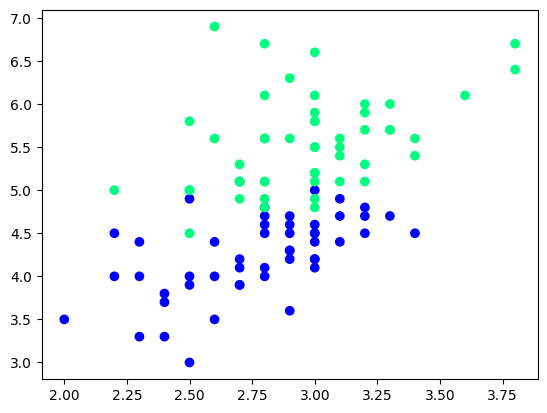

In [18]:
plt.scatter(df['sepal.width'],df['petal.length'],c=df['variety'],cmap='winter')

In [19]:
df_train = df.iloc[:60,:].sample(10)
df_train

,sepal.width,petal.length,variety
55,2.8,4.5,1
52,3.1,4.9,1
97,2.9,4.3,1
109,3.6,6.1,2
81,2.4,3.7,1
74,2.9,4.3,1
80,2.4,3.8,1
83,2.7,5.1,1
77,3.0,5.0,1
53,2.3,4.0,1


In [20]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [21]:
df_train

,sepal.width,petal.length,variety
132,2.8,5.6,2
123,2.7,4.9,2
50,3.2,4.7,1
54,2.8,4.6,1
76,2.8,4.8,1
138,3.0,4.8,2
143,3.2,5.9,2
119,2.2,5.0,2
92,2.6,4.0,1
77,3.0,5.0,1


In [22]:
df_val

,sepal.width,petal.length,variety
52,3.1,4.9,1
136,3.4,5.6,2
102,3.0,5.9,2
103,2.9,5.6,2
94,2.7,4.2,1


In [23]:
df_test

,sepal.width,petal.length,variety
101,2.7,5.1,2
133,2.8,5.1,2
128,2.8,5.6,2
82,2.7,3.9,1
134,2.6,5.6,2


In [24]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [25]:
y_test

array([1, 2, 2, 2, 1])

# Case 1 - Bagging

In [26]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal.width,petal.length,variety
92,2.6,4.0,1
50,3.2,4.7,1
143,3.2,5.9,2
123,2.7,4.9,2
54,2.8,4.6,1
143,3.2,5.9,2
123,2.7,4.9,2
132,2.8,5.6,2


In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [32]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

In [33]:
dt_bag1 = DecisionTreeClassifier()

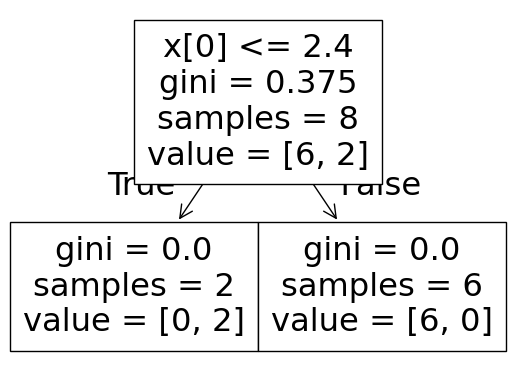

c:\Users\umair\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\umair\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.4


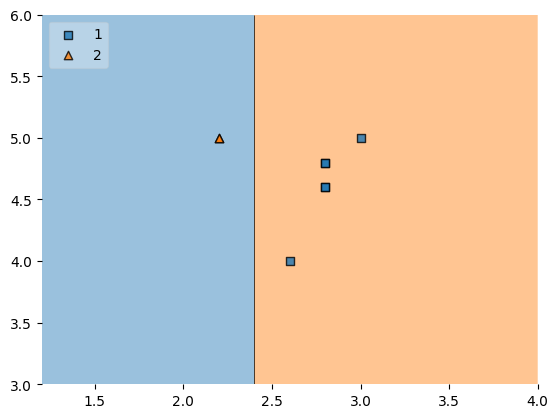

In [34]:
evaluate(dt_bag1,X,y)

In [35]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal.width,petal.length,variety
50,3.2,4.7,1
132,2.8,5.6,2
76,2.8,4.8,1
119,2.2,5.0,2
143,3.2,5.9,2
132,2.8,5.6,2
143,3.2,5.9,2
132,2.8,5.6,2


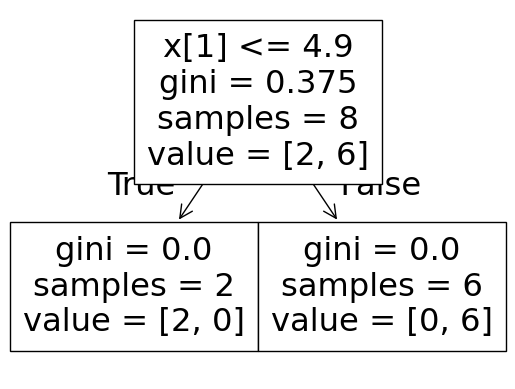

c:\Users\umair\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\umair\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


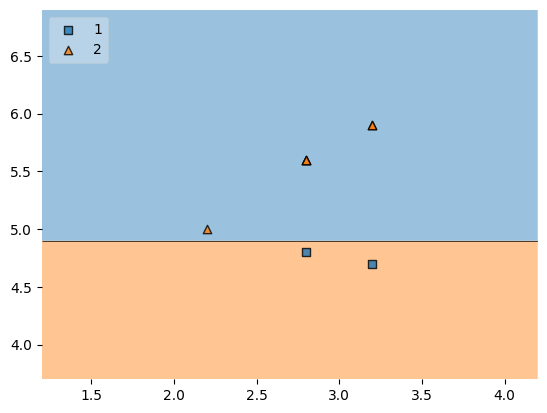

In [36]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [37]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal.width,petal.length,variety
50,3.2,4.7,1
138,3.0,4.8,2
138,3.0,4.8,2
132,2.8,5.6,2
77,3.0,5.0,1
132,2.8,5.6,2
119,2.2,5.0,2
92,2.6,4.0,1


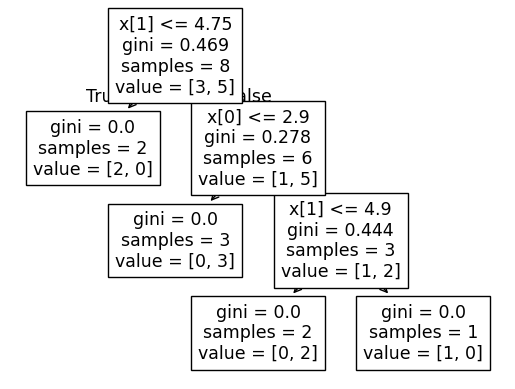

c:\Users\umair\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\umair\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.2


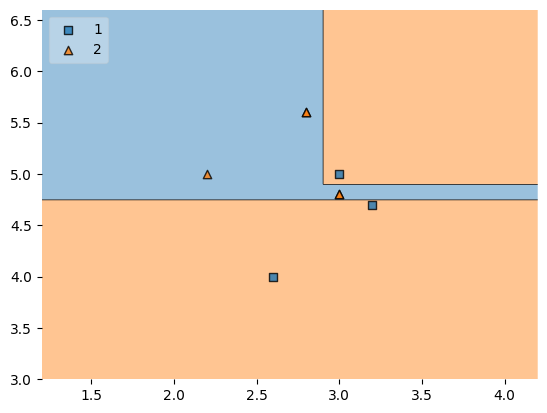

In [38]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

## Predict

In [39]:
df_test

,sepal.width,petal.length,variety
101,2.7,5.1,2
133,2.8,5.1,2
128,2.8,5.6,2
82,2.7,3.9,1
134,2.6,5.6,2


In [40]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


c:\Users\umair\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\umair\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\umair\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

In [41]:
# Row sampling without replacement
df_train

,sepal.width,petal.length,variety
132,2.8,5.6,2
123,2.7,4.9,2
50,3.2,4.7,1
54,2.8,4.6,1
76,2.8,4.8,1
138,3.0,4.8,2
143,3.2,5.9,2
119,2.2,5.0,2
92,2.6,4.0,1
77,3.0,5.0,1


In [42]:
df_train.sample(8)

,sepal.width,petal.length,variety
54,2.8,4.6,1
92,2.6,4.0,1
143,3.2,5.9,2
76,2.8,4.8,1
119,2.2,5.0,2
123,2.7,4.9,2
132,2.8,5.6,2
138,3.0,4.8,2


# Random Subspaces

In [48]:
df1 = pd.read_csv('iris.csv')
df1 = df1.sample(10)

In [49]:
df1

,sepal.length,sepal.width,petal.length,petal.width,variety
89,5.5,2.5,4.0,1.3,Versicolor
62,6.0,2.2,4.0,1.0,Versicolor
58,6.6,2.9,4.6,1.3,Versicolor
59,5.2,2.7,3.9,1.4,Versicolor
138,6.0,3.0,4.8,1.8,Virginica
63,6.1,2.9,4.7,1.4,Versicolor
22,4.6,3.6,1.0,0.2,Setosa
113,5.7,2.5,5.0,2.0,Virginica
20,5.4,3.4,1.7,0.2,Setosa
31,5.4,3.4,1.5,0.4,Setosa


In [50]:
df1.sample(2,replace=True,axis=1)

,sepal.width,petal.width
89,2.5,1.3
62,2.2,1.0
58,2.9,1.3
59,2.7,1.4
138,3.0,1.8
63,2.9,1.4
22,3.6,0.2
113,2.5,2.0
20,3.4,0.2
31,3.4,0.4


# Random Patches

In [51]:
df1

,sepal.length,sepal.width,petal.length,petal.width,variety
89,5.5,2.5,4.0,1.3,Versicolor
62,6.0,2.2,4.0,1.0,Versicolor
58,6.6,2.9,4.6,1.3,Versicolor
59,5.2,2.7,3.9,1.4,Versicolor
138,6.0,3.0,4.8,1.8,Virginica
63,6.1,2.9,4.7,1.4,Versicolor
22,4.6,3.6,1.0,0.2,Setosa
113,5.7,2.5,5.0,2.0,Virginica
20,5.4,3.4,1.7,0.2,Setosa
31,5.4,3.4,1.5,0.4,Setosa


In [52]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,variety,sepal.width
63,Versicolor,2.9
20,Setosa,3.4
63,Versicolor,2.9
31,Setosa,3.4
62,Versicolor,2.2
58,Versicolor,2.9
138,Virginica,3.0
58,Versicolor,2.9
